In [1]:
import pandas as pd
from functools import reduce

paths = {
    "tabular": "../data/tabular_embeddings.csv",
    "temporal": "../data/temporal_embeddings.csv",
    "graph": "../data/graph_embeddings.csv"

}



In [2]:
dfs = {k: pd.read_csv(v) for k, v in paths.items()}

for k, df in dfs.items():
    print(k, df.shape)


tabular (15420, 20)
temporal (15420, 19)
graph (15420, 35)


In [3]:
df = reduce(
    lambda left, right: pd.merge(left, right, on=["claim_id", "fraudfound_p"]),
    dfs.values()
)

print("Merged shape:", df.shape)


Merged shape: (15420, 70)


In [4]:
drop_cols = ["claim_id", "fraudfound_p"]
bad_cols = [c for c in df.columns if "leaf" in c or "raw_score" in c]

df = df.drop(columns=drop_cols + bad_cols, errors="ignore")


In [5]:
df["avg_prob"] = (
    df["tabular_fraud_probability"] +
    df["temporal_fraud_probability"] +
    df["graph_fraud_probability"]
) / 3

df["max_prob"] = df[
    ["tabular_fraud_probability",
     "temporal_fraud_probability",
     "graph_fraud_probability"]
].max(axis=1)

df["min_prob"] = df[
    ["tabular_fraud_probability",
     "temporal_fraud_probability",
     "graph_fraud_probability"]
].min(axis=1)

# weighted signal (MOST IMPORTANT)
df["weighted_score"] = (
    0.7 * df["tabular_fraud_probability"] +
    0.2 * df["graph_fraud_probability"] +
    0.1 * df["temporal_fraud_probability"]
)

# interactions
df["tab_x_graph"] = df["tabular_fraud_probability"] * df["graph_fraud_probability"]
df["tab_x_temp"] = df["tabular_fraud_probability"] * df["temporal_fraud_probability"]

# differences
df["tab_graph_diff"] = abs(
    df["tabular_fraud_probability"] - df["graph_fraud_probability"]
)

df["tab_temp_diff"] = abs(
    df["tabular_fraud_probability"] - df["temporal_fraud_probability"]
)

# 🔥 anchor strongest model
df["final_hint"] = df["tabular_fraud_probability"]


In [6]:

y = dfs["tabular"]["fraudfound_p"].values
X = df.values

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_auc_score
import copy

class FusionDNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze()

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

In [11]:
class_counts = np.bincount(y_train.numpy().astype(int))
pos_weight = torch.tensor([class_counts[0] / class_counts[1]])

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

In [12]:


model = FusionDNN(input_dim=X_train.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

best_auc = 0
best_model = copy.deepcopy(model.state_dict())
patience = 5
patience_counter = 0

for epoch in range(50):
    model.train()

    logits = model(X_train)
    loss = criterion(logits, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_test)).numpy()
        auc = roc_auc_score(y_test, probs)

    print(f"Epoch {epoch} | Loss {loss.item():.4f} | AUC {auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        best_model = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping triggered")
        break

# load best model
model.load_state_dict(best_model)
print("Best AUC:", best_auc)

Epoch 0 | Loss 1.2755 | AUC 0.7489
Epoch 1 | Loss 1.2358 | AUC 0.7765
Epoch 2 | Loss 1.1990 | AUC 0.7917
Epoch 3 | Loss 1.1647 | AUC 0.7997
Epoch 4 | Loss 1.1324 | AUC 0.8045
Epoch 5 | Loss 1.1020 | AUC 0.8076
Epoch 6 | Loss 1.0735 | AUC 0.8099
Epoch 7 | Loss 1.0466 | AUC 0.8115
Epoch 8 | Loss 1.0213 | AUC 0.8131
Epoch 9 | Loss 0.9975 | AUC 0.8144
Epoch 10 | Loss 0.9751 | AUC 0.8156
Epoch 11 | Loss 0.9542 | AUC 0.8168
Epoch 12 | Loss 0.9346 | AUC 0.8179
Epoch 13 | Loss 0.9164 | AUC 0.8191
Epoch 14 | Loss 0.8995 | AUC 0.8203
Epoch 15 | Loss 0.8838 | AUC 0.8214
Epoch 16 | Loss 0.8692 | AUC 0.8225
Epoch 17 | Loss 0.8555 | AUC 0.8238
Epoch 18 | Loss 0.8426 | AUC 0.8249
Epoch 19 | Loss 0.8305 | AUC 0.8258
Epoch 20 | Loss 0.8189 | AUC 0.8266
Epoch 21 | Loss 0.8078 | AUC 0.8272
Epoch 22 | Loss 0.7971 | AUC 0.8278
Epoch 23 | Loss 0.7865 | AUC 0.8282
Epoch 24 | Loss 0.7762 | AUC 0.8286
Epoch 25 | Loss 0.7659 | AUC 0.8288
Epoch 26 | Loss 0.7557 | AUC 0.8290
Epoch 27 | Loss 0.7456 | AUC 0.8291
Ep

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

model.eval()
with torch.no_grad():
    fraud_scores = torch.sigmoid(model(X_test)).numpy()

pred_labels = (fraud_scores >= 0.5).astype(int)
true_labels = y_test.numpy().astype(int)

accuracy = (pred_labels == true_labels).mean()
precision = precision_score(true_labels, pred_labels, zero_division=0)
recall = recall_score(true_labels, pred_labels, zero_division=0)
f1 = f1_score(true_labels, pred_labels, zero_division=0)
auc = roc_auc_score(true_labels, fraud_scores)
cm = confusion_matrix(true_labels, pred_labels)

print("Test Accuracy @0.5:", round(float(accuracy), 4))
print("Precision:", round(float(precision), 4))
print("Recall:", round(float(recall), 4))
print("F1 Score:", round(float(f1), 4))
print("ROC-AUC:", round(float(auc), 4))
print("Confusion Matrix [[TN, FP], [FN, TP]]:")
print(cm)
print("Sample fraud scores:", fraud_scores[:10])

Test Accuracy @0.5: 0.6848
Precision: 0.1406
Recall: 0.8324
F1 Score: 0.2406
ROC-AUC: 0.8291
Confusion Matrix [[TN, FP], [FN, TP]]:
[[1958  941]
 [  31  154]]
Sample fraud scores: [0.15348487 0.5119371  0.2764538  0.82498616 0.22934572 0.57883334
 0.3150877  0.8560376  0.28921536 0.2862268 ]


Recall target: 0.8

Selector A (precision-first): max precision with recall >= 0.80
Selected threshold: 0.54
Precision: 0.1487 | Recall: 0.8 | F1: 0.2508
Confusion Matrix [[TN, FP], [FN, TP]]:
[[2052  847]
 [  37  148]]

Selector B (minimum business cost)
Costs used -> FP: 1.0, FN: 25.0
Selected threshold: 0.39
Precision: 0.1287 | Recall: 0.9297 | F1: 0.2262 | Business cost: 1489.0
Confusion Matrix [[TN, FP], [FN, TP]]:
[[1735 1164]
 [  13  172]]

PR-AUC (Average Precision): 0.2259

Top threshold candidates by precision (meeting recall target):
    threshold  precision  recall      f1    tn    fp  fn   tp  business_cost
49       0.54     0.1487  0.8000  0.2508  2052   847  37  148         1772.0
48       0.53     0.1444  0.8000  0.2446  2022   877  37  148         1802.0
47       0.52     0.1437  0.8108  0.2441  2005   894  35  150         1769.0
46       0.51     0.1415  0.8162  0.2412  1983   916  34  151         1766.0
44       0.49     0.1407  0.8541  0.2416  1934   965  27  158   

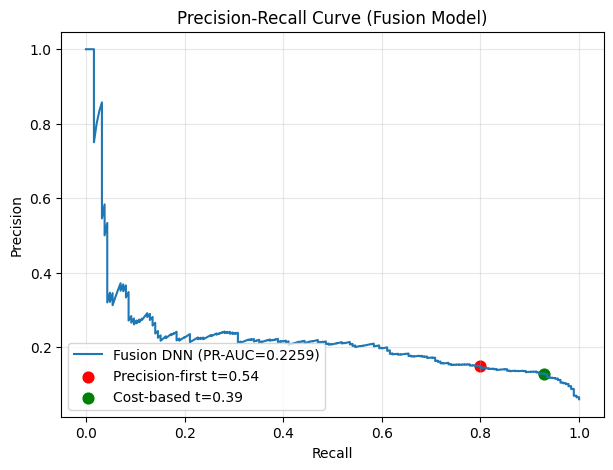

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve

# Threshold tuning for business objective.
# Goal: maximize precision while keeping recall above a minimum acceptable level.
min_recall_target = 0.80

# Cost-based selector: adjust these with business inputs.
fp_cost = 1.0   # cost of investigating a false alarm
fn_cost = 25.0  # cost of missing an actual fraud

threshold_grid = np.linspace(0.05, 0.95, 91)
rows = []
for t in threshold_grid:
    pred_t = (fraud_scores >= t).astype(int)
    p_t = precision_score(true_labels, pred_t, zero_division=0)
    r_t = recall_score(true_labels, pred_t, zero_division=0)
    f1_t = f1_score(true_labels, pred_t, zero_division=0)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(true_labels, pred_t).ravel()
    total_cost_t = fp_t * fp_cost + fn_t * fn_cost

    rows.append((t, p_t, r_t, f1_t, tn_t, fp_t, fn_t, tp_t, total_cost_t))

threshold_df = pd.DataFrame(
    rows,
    columns=["threshold", "precision", "recall", "f1", "tn", "fp", "fn", "tp", "business_cost"]
)

# Selector A: precision-first under recall constraint.
candidates = threshold_df[threshold_df["recall"] >= min_recall_target].copy()
if len(candidates) > 0:
    best_row = candidates.sort_values(["precision", "f1"], ascending=False).iloc[0]
    selection_reason = f"max precision with recall >= {min_recall_target:.2f}"
else:
    best_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
    selection_reason = "fallback to max F1 (no threshold met recall target)"

best_threshold = float(best_row["threshold"])
best_pred = (fraud_scores >= best_threshold).astype(int)
best_cm = confusion_matrix(true_labels, best_pred)

# Selector B: minimum business cost.
cost_best_row = threshold_df.sort_values("business_cost", ascending=True).iloc[0]
cost_best_threshold = float(cost_best_row["threshold"])
cost_best_pred = (fraud_scores >= cost_best_threshold).astype(int)
cost_best_cm = confusion_matrix(true_labels, cost_best_pred)

pr_auc = average_precision_score(true_labels, fraud_scores)

print("Recall target:", min_recall_target)
print("\nSelector A (precision-first):", selection_reason)
print("Selected threshold:", round(best_threshold, 3))
print("Precision:", round(float(best_row["precision"]), 4),
      "| Recall:", round(float(best_row["recall"]), 4),
      "| F1:", round(float(best_row["f1"]), 4))
print("Confusion Matrix [[TN, FP], [FN, TP]]:")
print(best_cm)

print("\nSelector B (minimum business cost)")
print(f"Costs used -> FP: {fp_cost}, FN: {fn_cost}")
print("Selected threshold:", round(cost_best_threshold, 3))
print("Precision:", round(float(cost_best_row["precision"]), 4),
      "| Recall:", round(float(cost_best_row["recall"]), 4),
      "| F1:", round(float(cost_best_row["f1"]), 4),
      "| Business cost:", round(float(cost_best_row["business_cost"]), 2))
print("Confusion Matrix [[TN, FP], [FN, TP]]:")
print(cost_best_cm)

print("\nPR-AUC (Average Precision):", round(float(pr_auc), 4))

print("\nTop threshold candidates by precision (meeting recall target):")
if len(candidates) > 0:
    print(candidates.sort_values(["precision", "f1"], ascending=False).head(10).round(4))
else:
    print("No thresholds satisfied recall target; showing top F1 thresholds instead.")
    print(threshold_df.sort_values("f1", ascending=False).head(10).round(4))

print("\nTop threshold candidates by lowest business cost:")
print(threshold_df.sort_values("business_cost", ascending=True).head(10).round(4))

# Precision-Recall curve.
curve_precision, curve_recall, curve_thresholds = precision_recall_curve(true_labels, fraud_scores)

plt.figure(figsize=(7, 5))
plt.plot(curve_recall, curve_precision, label=f"Fusion DNN (PR-AUC={pr_auc:.4f})")
plt.scatter(float(best_row["recall"]), float(best_row["precision"]),
            color="red", s=60, label=f"Precision-first t={best_threshold:.2f}")
plt.scatter(float(cost_best_row["recall"]), float(cost_best_row["precision"]),
            color="green", s=60, label=f"Cost-based t={cost_best_threshold:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Fusion Model)")
plt.grid(alpha=0.3)
plt.legend(loc="lower left")
plt.show()

In [ ]:
# Retrain with focal loss to reduce false positives under class imbalance.
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = nn.functional.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_factor = (1 - pt).pow(self.gamma)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        loss = alpha_t * focal_factor * bce_loss

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def train_and_score(model_obj, loss_fn, x_train, y_train_t, x_valid, y_valid_t, max_epochs=50, lr=0.0005, patience=5):
    opt = torch.optim.Adam(model_obj.parameters(), lr=lr)
    best_auc_local = 0.0
    best_state = copy.deepcopy(model_obj.state_dict())
    patience_ctr = 0

    for ep in range(max_epochs):
        model_obj.train()
        logits_local = model_obj(x_train)
        loss_local = loss_fn(logits_local, y_train_t)

        opt.zero_grad()
        loss_local.backward()
        opt.step()

        model_obj.eval()
        with torch.no_grad():
            probs_local = torch.sigmoid(model_obj(x_valid)).numpy()
            auc_local = roc_auc_score(y_valid_t.numpy().astype(int), probs_local)

        if auc_local > best_auc_local:
            best_auc_local = auc_local
            best_state = copy.deepcopy(model_obj.state_dict())
            patience_ctr = 0
        else:
            patience_ctr += 1

        if patience_ctr >= patience:
            break

    model_obj.load_state_dict(best_state)
    model_obj.eval()
    with torch.no_grad():
        final_scores = torch.sigmoid(model_obj(x_valid)).numpy()

    return final_scores, best_auc_local


def summarize_thresholds(scores, label_name, min_recall):
    pr_auc_local = average_precision_score(true_labels, scores)
    rows_local = []
    for t in threshold_grid:
        pred_t = (scores >= t).astype(int)
        p_t = precision_score(true_labels, pred_t, zero_division=0)
        r_t = recall_score(true_labels, pred_t, zero_division=0)
        f1_t = f1_score(true_labels, pred_t, zero_division=0)
        rows_local.append((t, p_t, r_t, f1_t))

    local_df = pd.DataFrame(rows_local, columns=["threshold", "precision", "recall", "f1"])
    local_candidates = local_df[local_df["recall"] >= min_recall].copy()

    if len(local_candidates) > 0:
        local_best = local_candidates.sort_values(["precision", "f1"], ascending=False).iloc[0]
    else:
        local_best = local_df.sort_values("f1", ascending=False).iloc[0]

    return {
        "model": label_name,
        "pr_auc": float(pr_auc_local),
        "threshold": float(local_best["threshold"]),
        "precision": float(local_best["precision"]),
        "recall": float(local_best["recall"]),
        "f1": float(local_best["f1"]),
    }


run_focal_experiment = True

if run_focal_experiment:
    focal_configs = [
        (0.85, 1.5),
        (0.85, 3.0),
        (0.75, 2.0),
    ]

    experiment_rows = []

    # Include current base model result for direct comparison.
    base_result = {
        "model": "base_bce",
        "alpha": np.nan,
        "gamma": np.nan,
        "roc_auc": float(auc),
        **summarize_thresholds(fraud_scores, "base_bce", min_recall_target),
    }
    experiment_rows.append(base_result)

    for alpha_val, gamma_val in focal_configs:
        focal_model = FusionDNN(input_dim=X_train.shape[1])
        focal_loss = FocalLoss(alpha=alpha_val, gamma=gamma_val)

        focal_scores, focal_best_auc = train_and_score(
            focal_model,
            focal_loss,
            X_train,
            y_train,
            X_test,
            y_test,
            max_epochs=50,
            lr=0.0005,
            patience=5,
        )

        summary = summarize_thresholds(
            focal_scores,
            f"focal_a{alpha_val}_g{gamma_val}",
            min_recall_target,
        )
        summary.update({
            "alpha": alpha_val,
            "gamma": gamma_val,
            "roc_auc": float(focal_best_auc),
        })
        experiment_rows.append(summary)

    experiment_df = pd.DataFrame(experiment_rows)

    rank_df = experiment_df.copy()
    rank_df["score"] = rank_df["precision"] * 0.7 + rank_df["recall"] * 0.3
    best_idx = rank_df["score"].idxmax()

    print("Focal sweep summary (evaluated at precision-first threshold under recall target):")
    print(experiment_df[["model", "alpha", "gamma", "roc_auc", "pr_auc", "threshold", "precision", "recall", "f1"]].round(4))

    print("\nBest config by score = 0.7*precision + 0.3*recall:")
    print(rank_df.loc[[best_idx], ["model", "alpha", "gamma", "roc_auc", "pr_auc", "threshold", "precision", "recall", "f1", "score"]].round(4))
else:
    print("Set run_focal_experiment = True to run focal-loss retraining.")

Focal sweep summary (evaluated at precision-first threshold under recall target):
              model  alpha  gamma  roc_auc  pr_auc  threshold  precision  \
0          base_bce    NaN    NaN   0.8291  0.2259       0.54     0.1487   
1  focal_a0.85_g1.5   0.85    1.5   0.8210  0.2087       0.46     0.1455   
2  focal_a0.85_g3.0   0.85    3.0   0.8074  0.1961       0.46     0.1499   
3  focal_a0.75_g2.0   0.75    2.0   0.8038  0.1988       0.48     0.1475   

   recall      f1  
0  0.8000  0.2508  
1  0.8216  0.2472  
2  0.8000  0.2526  
3  0.8054  0.2494  

Best config by score = 0.7*precision + 0.3*recall:
              model  alpha  gamma  roc_auc  pr_auc  threshold  precision  \
1  focal_a0.85_g1.5   0.85    1.5    0.821  0.2087       0.46     0.1455   

   recall      f1   score  
1  0.8216  0.2472  0.3483  
